[ WARN:0@1.446] global loadsave.cpp:278 findDecoder imread_('benchmark.jpg'): can't open/read file: check file path/integrity


指定された画像が見つからないため、テスト画像を自動生成します。


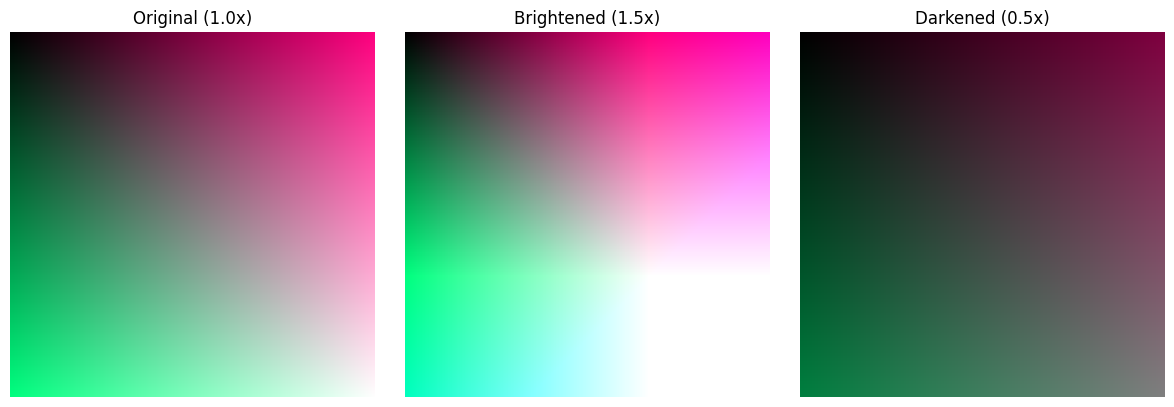

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. ベンチマーク画像の読み込み（または擬似的なテスト画像の生成）
try:
    img = cv2.imread('benchmark.jpg')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
except:
    print("指定された画像が見つからないため、テスト画像を自動生成します。")
    # 縦横に綺麗なグラデーションを作るよう修正
    x = np.linspace(0, 255, 400, dtype=np.uint8)
    y = np.linspace(0, 255, 400, dtype=np.uint8)
    X, Y = np.meshgrid(x, y)
    Z = ((X.astype(np.float32) + Y.astype(np.float32)) / 2).astype(np.uint8)
    img = np.stack([X, Y, Z], axis=-1)

# 2. 1x1フィルタ（カーネル）の定義
kernel_brighten = np.array([[1.5]], dtype=np.float32)
kernel_darken = np.array([[0.5]], dtype=np.float32)

# 3. フィルタの適用 (ddepthに cv2.CV_32F を指定して計算中の型落ちを防ぐ)
# 計算結果を一度 float32 で受け取ります
img_bright_f = cv2.filter2D(img.astype(np.float32), cv2.CV_32F, kernel_brighten)
img_dark_f = cv2.filter2D(img.astype(np.float32), cv2.CV_32F, kernel_darken)

# 4. 安全なクリップ処理と型変換
# 0未満は0に、255を超えるものは255に固定して、uint8に戻す
img_bright = np.clip(img_bright_f, 0, 255).astype(np.uint8)
img_dark = np.clip(img_dark_f, 0, 255).astype(np.uint8)

# 5. 結果の可視化
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original (1.0x)")
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Brightened (1.5x)")
plt.imshow(img_bright)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Darkened (0.5x)")
plt.imshow(img_dark)
plt.axis('off')

plt.tight_layout()
plt.show()